In [1]:
import polars as pl

schema = {
    "PERMNO": pl.Int32,    # firm identifier
    "date": pl.Utf8,       
    "SICCD": pl.Int32,     # SIC code
    "RET": pl.Float64,    # returns
    "RETX": pl.Float64,    # return (excluding dividends)
    "vwretd": pl.Float64,   # value-weighted return
    "SHROUT": pl.Int64,
    "PRC": pl.Float64
}

# assume df is your CRSP dataset loaded into Polars
df = pl.read_csv(
    "MSF_1996_2023.csv",
    schema_overrides=schema,
    try_parse_dates=False,
    null_values=["", "NA", "NaN", "B"],  # treat "B" as missing
    ignore_errors=True,
)

# ==== Parse date column ====
df = df.with_columns(
    pl.col("date").str.strptime(pl.Date, format="%m/%d/%Y")
)

# ==== Add year and month columns for convenience ====
df = df.with_columns([
    pl.col("date").dt.year().alias("year"),
    pl.col("date").dt.month().alias("month")
])

expr = (
    pl.when((pl.col("SICCD") >= 1) & (pl.col("SICCD") <= 999)).then(pl.lit("Agriculture"))
    .when((pl.col("SICCD") >= 1000) & (pl.col("SICCD") <= 1499)).then(pl.lit("Mining"))
    .when((pl.col("SICCD") >= 1500) & (pl.col("SICCD") <= 1799)).then(pl.lit("Construction"))
    .when((pl.col("SICCD") >= 2000) & (pl.col("SICCD") <= 3999)).then(pl.lit("Manufacturing"))
    .when((pl.col("SICCD") >= 4000) & (pl.col("SICCD") <= 4999)).then(pl.lit("Transportation"))
    .when((pl.col("SICCD") >= 5000) & (pl.col("SICCD") <= 5199)).then(pl.lit("Wholesale"))
    .when((pl.col("SICCD") >= 5200) & (pl.col("SICCD") <= 5999)).then(pl.lit("Retail"))
    .when((pl.col("SICCD") >= 6000) & (pl.col("SICCD") <= 6799)).then(pl.lit("Finance"))
    .when((pl.col("SICCD") >= 7000) & (pl.col("SICCD") <= 8999)).then(pl.lit("Services"))
    .when((pl.col("SICCD") >= 9000) & (pl.col("SICCD") <= 9999)).then(pl.lit("PublicAdmin"))
    .otherwise(pl.lit("Other"))
    .alias("industry")
)

df = df.with_columns(expr)

In [2]:
df.head(5)

PERMNO,date,SICCD,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,RETX,vwretd,year,month,industry
i32,date,i32,str,str,i64,f64,i64,f64,i64,f64,f64,i32,i8,str
10001,1996-01-31,4920,"""EWST""","""ENERGY WEST INC""",7953,-9.125,168,-0.026667,2281,-0.026667,0.028121,1996,1,"""Transportation"""
10001,1996-02-29,4920,"""EWST""","""ENERGY WEST INC""",7953,9.25,524,0.013699,2281,0.013699,0.016353,1996,2,"""Transportation"""
10001,1996-03-29,4920,"""EWST""","""ENERGY WEST INC""",7953,9.48438,283,0.036149,2309,0.025338,0.010914,1996,3,"""Transportation"""
10001,1996-04-30,4920,"""EWST""","""ENERGY WEST INC""",7953,-8.8125,327,-0.07084,2309,-0.07084,0.02556,1996,4,"""Transportation"""
10001,1996-05-31,4920,"""EWST""","""ENERGY WEST INC""",7953,8.625,103,-0.021277,2309,-0.021277,0.02681,1996,5,"""Transportation"""


In [4]:
df = df.sort(["PERMNO", "date"])
df = df.with_columns(
    (
        ((pl.col("RETX").shift(-1).abs() > 0.1))
        .cast(pl.Int8)
        .alias("jump")
    ).over("PERMNO")
)

df.head()

PERMNO,date,SICCD,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,RETX,vwretd,year,month,industry,jump
i32,date,i32,str,str,i64,f64,i64,f64,i64,f64,f64,i32,i8,str,i8
10001,1996-01-31,4920,"""EWST""","""ENERGY WEST INC""",7953,-9.125,168,-0.026667,2281,-0.026667,0.028121,1996,1,"""Transportation""",0
10001,1996-02-29,4920,"""EWST""","""ENERGY WEST INC""",7953,9.25,524,0.013699,2281,0.013699,0.016353,1996,2,"""Transportation""",0
10001,1996-03-29,4920,"""EWST""","""ENERGY WEST INC""",7953,9.48438,283,0.036149,2309,0.025338,0.010914,1996,3,"""Transportation""",0
10001,1996-04-30,4920,"""EWST""","""ENERGY WEST INC""",7953,-8.8125,327,-0.07084,2309,-0.07084,0.02556,1996,4,"""Transportation""",0
10001,1996-05-31,4920,"""EWST""","""ENERGY WEST INC""",7953,8.625,103,-0.021277,2309,-0.021277,0.02681,1996,5,"""Transportation""",0


In [5]:
# Calculate the percentage of jumps in df
total_obs = df.height
num_jumps = df["jump"].sum()
jump_percentage = (num_jumps / total_obs) * 100
print(f"Percentage of jumps: {jump_percentage:.2f}%")


Percentage of jumps: 35.68%


In [6]:
import os

# Path to the macro folder
macro_folder = "macros"

# List all CSV files in the macro folder
macro_files = [f for f in os.listdir(macro_folder) if f.endswith(".csv")]

# Load each CSV file into a dictionary of DataFrames
macro_dfs = {}
for fname in macro_files:
    key = os.path.splitext(fname)[0]
    macro_dfs[key] = pl.read_csv(os.path.join(macro_folder, fname))

# Optionally, display the keys loaded
print("Loaded macro datasets:", list(macro_dfs.keys()))


Loaded macro datasets: ['AAA', 'BAA', 'FEDFUNDS', 'M2REAL', 'T10Y2YM', 'UNRATE', 'USREC', 'VIXCLS']


In [7]:
# Combine macro datasets into one big DataFrame with year, month, AAA, BAA, etc.

# First, add year and month columns to each macro DataFrame
new_macro_dfs = {}
for key, mdf in macro_dfs.items():
    # Some macro files may already have year/month, but this is safe
    mdf = mdf.with_columns([
        pl.col("observation_date").str.to_date().dt.year().alias("year"),
        pl.col("observation_date").str.to_date().dt.month().alias("month")
    ])
    new_macro_dfs[key] = mdf

# Prepare VIXCLS: compute monthly average and max
if "VIXCLS" in new_macro_dfs:
    vix_df = new_macro_dfs["VIXCLS"]
    vix_monthly = (
        vix_df
        .group_by(["year", "month"])
        .agg([
            pl.col("VIXCLS").last().alias("VIXCLS_last")
        ])
    )
    new_macro_dfs["VIXCLS"] = vix_monthly


import itertools

years = list(range(1996, 2024))
months = list(range(1, 13))
year_month_pairs = list(itertools.product(years, months))
macro_big = pl.DataFrame({
    "year": pl.Series("year", [y for y, m in year_month_pairs], dtype=pl.Int32),
    "month": pl.Series("month", [m for y, m in year_month_pairs], dtype=pl.Int8)
})
# Join in other macro variables (e.g., UNRATE, FEDFUNDS, etc.)
for key in new_macro_dfs:

    mdf = new_macro_dfs[key]
    # Try to use VALUE column if it exists
    if key in mdf.columns and key!='VIXCLS':
        macro_big = macro_big.join(
            mdf.select(["year", "month", key]),
            on=["year", "month"],
            how="left"
        )
    # Otherwise, try to use the key as the column name (e.g., for VIXCLS_monthly)
    elif key == 'VIXCLS':
        macro_big = macro_big.join(
            mdf.select(["year", "month", 'VIXCLS_last']),
            on=["year", "month"],
            how="left"
        )

# Add credit risk column: BAA - AAA
if "BAA" in macro_big.columns and "AAA" in macro_big.columns:
    macro_big = macro_big.with_columns(
        (pl.col("BAA") - pl.col("AAA")).alias("credit_risk")
    )

# Optionally, show the first few rows
print(macro_big.head())


shape: (5, 11)
┌──────┬───────┬──────┬──────┬───┬────────┬───────┬─────────────┬─────────────┐
│ year ┆ month ┆ AAA  ┆ BAA  ┆ … ┆ UNRATE ┆ USREC ┆ VIXCLS_last ┆ credit_risk │
│ ---  ┆ ---   ┆ ---  ┆ ---  ┆   ┆ ---    ┆ ---   ┆ ---         ┆ ---         │
│ i32  ┆ i8    ┆ f64  ┆ f64  ┆   ┆ f64    ┆ i64   ┆ f64         ┆ f64         │
╞══════╪═══════╪══════╪══════╪═══╪════════╪═══════╪═════════════╪═════════════╡
│ 1996 ┆ 1     ┆ 6.81 ┆ 7.47 ┆ … ┆ 5.6    ┆ 0     ┆ 12.53       ┆ 0.66        │
│ 1996 ┆ 2     ┆ 6.99 ┆ 7.63 ┆ … ┆ 5.5    ┆ 0     ┆ 17.04       ┆ 0.64        │
│ 1996 ┆ 3     ┆ 7.35 ┆ 8.03 ┆ … ┆ 5.5    ┆ 0     ┆ 18.88       ┆ 0.68        │
│ 1996 ┆ 4     ┆ 7.5  ┆ 8.19 ┆ … ┆ 5.6    ┆ 0     ┆ 15.83       ┆ 0.69        │
│ 1996 ┆ 5     ┆ 7.62 ┆ 8.3  ┆ … ┆ 5.6    ┆ 0     ┆ 16.07       ┆ 0.68        │
└──────┴───────┴──────┴──────┴───┴────────┴───────┴─────────────┴─────────────┘


In [8]:
# Aggregate jumps by year and month and plot the monthly jump percentage (jump_pct) for all months from 1996 to 2023,

monthly_jumps = (
    df.group_by(["year", "month"])
      .agg([
          pl.col("jump").sum().alias("total_jumps"),
          pl.col("jump").count().alias("n_obs")
      ])
      .with_columns(
          (pl.col("total_jumps") / pl.col("n_obs") * 100).alias("jump_pct")
      )
      .sort(["year", "month"])
)

monthly_jumps = monthly_jumps.join(
    macro_big,
    on=["year", "month"],
    how="left"
)





In [9]:
monthly_jumps.head()

year,month,total_jumps,n_obs,jump_pct,AAA,BAA,FEDFUNDS,M2REAL,T10Y2YM,UNRATE,USREC,VIXCLS_last,credit_risk
i32,i8,i64,u32,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64
1996,1,2195,6671,32.903613,6.81,7.47,5.56,2358.0,0.54,5.6,0,12.53,0.66
1996,2,2209,6641,33.263063,6.99,7.63,5.22,2362.5,0.78,5.5,0,17.04,0.64
1996,3,2581,6605,39.076457,7.35,8.03,5.31,2371.0,0.61,5.5,0,18.88,0.68
1996,4,2357,6564,35.907983,7.5,8.19,5.22,2368.8,0.55,5.6,0,15.83,0.69
1996,5,2344,6528,35.906863,7.62,8.3,5.24,2371.9,0.64,5.6,0,16.07,0.68


In [10]:
# Drop AAA and BAA columns from monthly_jumps if they exist
cols_to_drop = [col for col in ["AAA", "BAA"] if col in monthly_jumps.columns]
if cols_to_drop:
    monthly_jumps = monthly_jumps.drop(cols_to_drop)


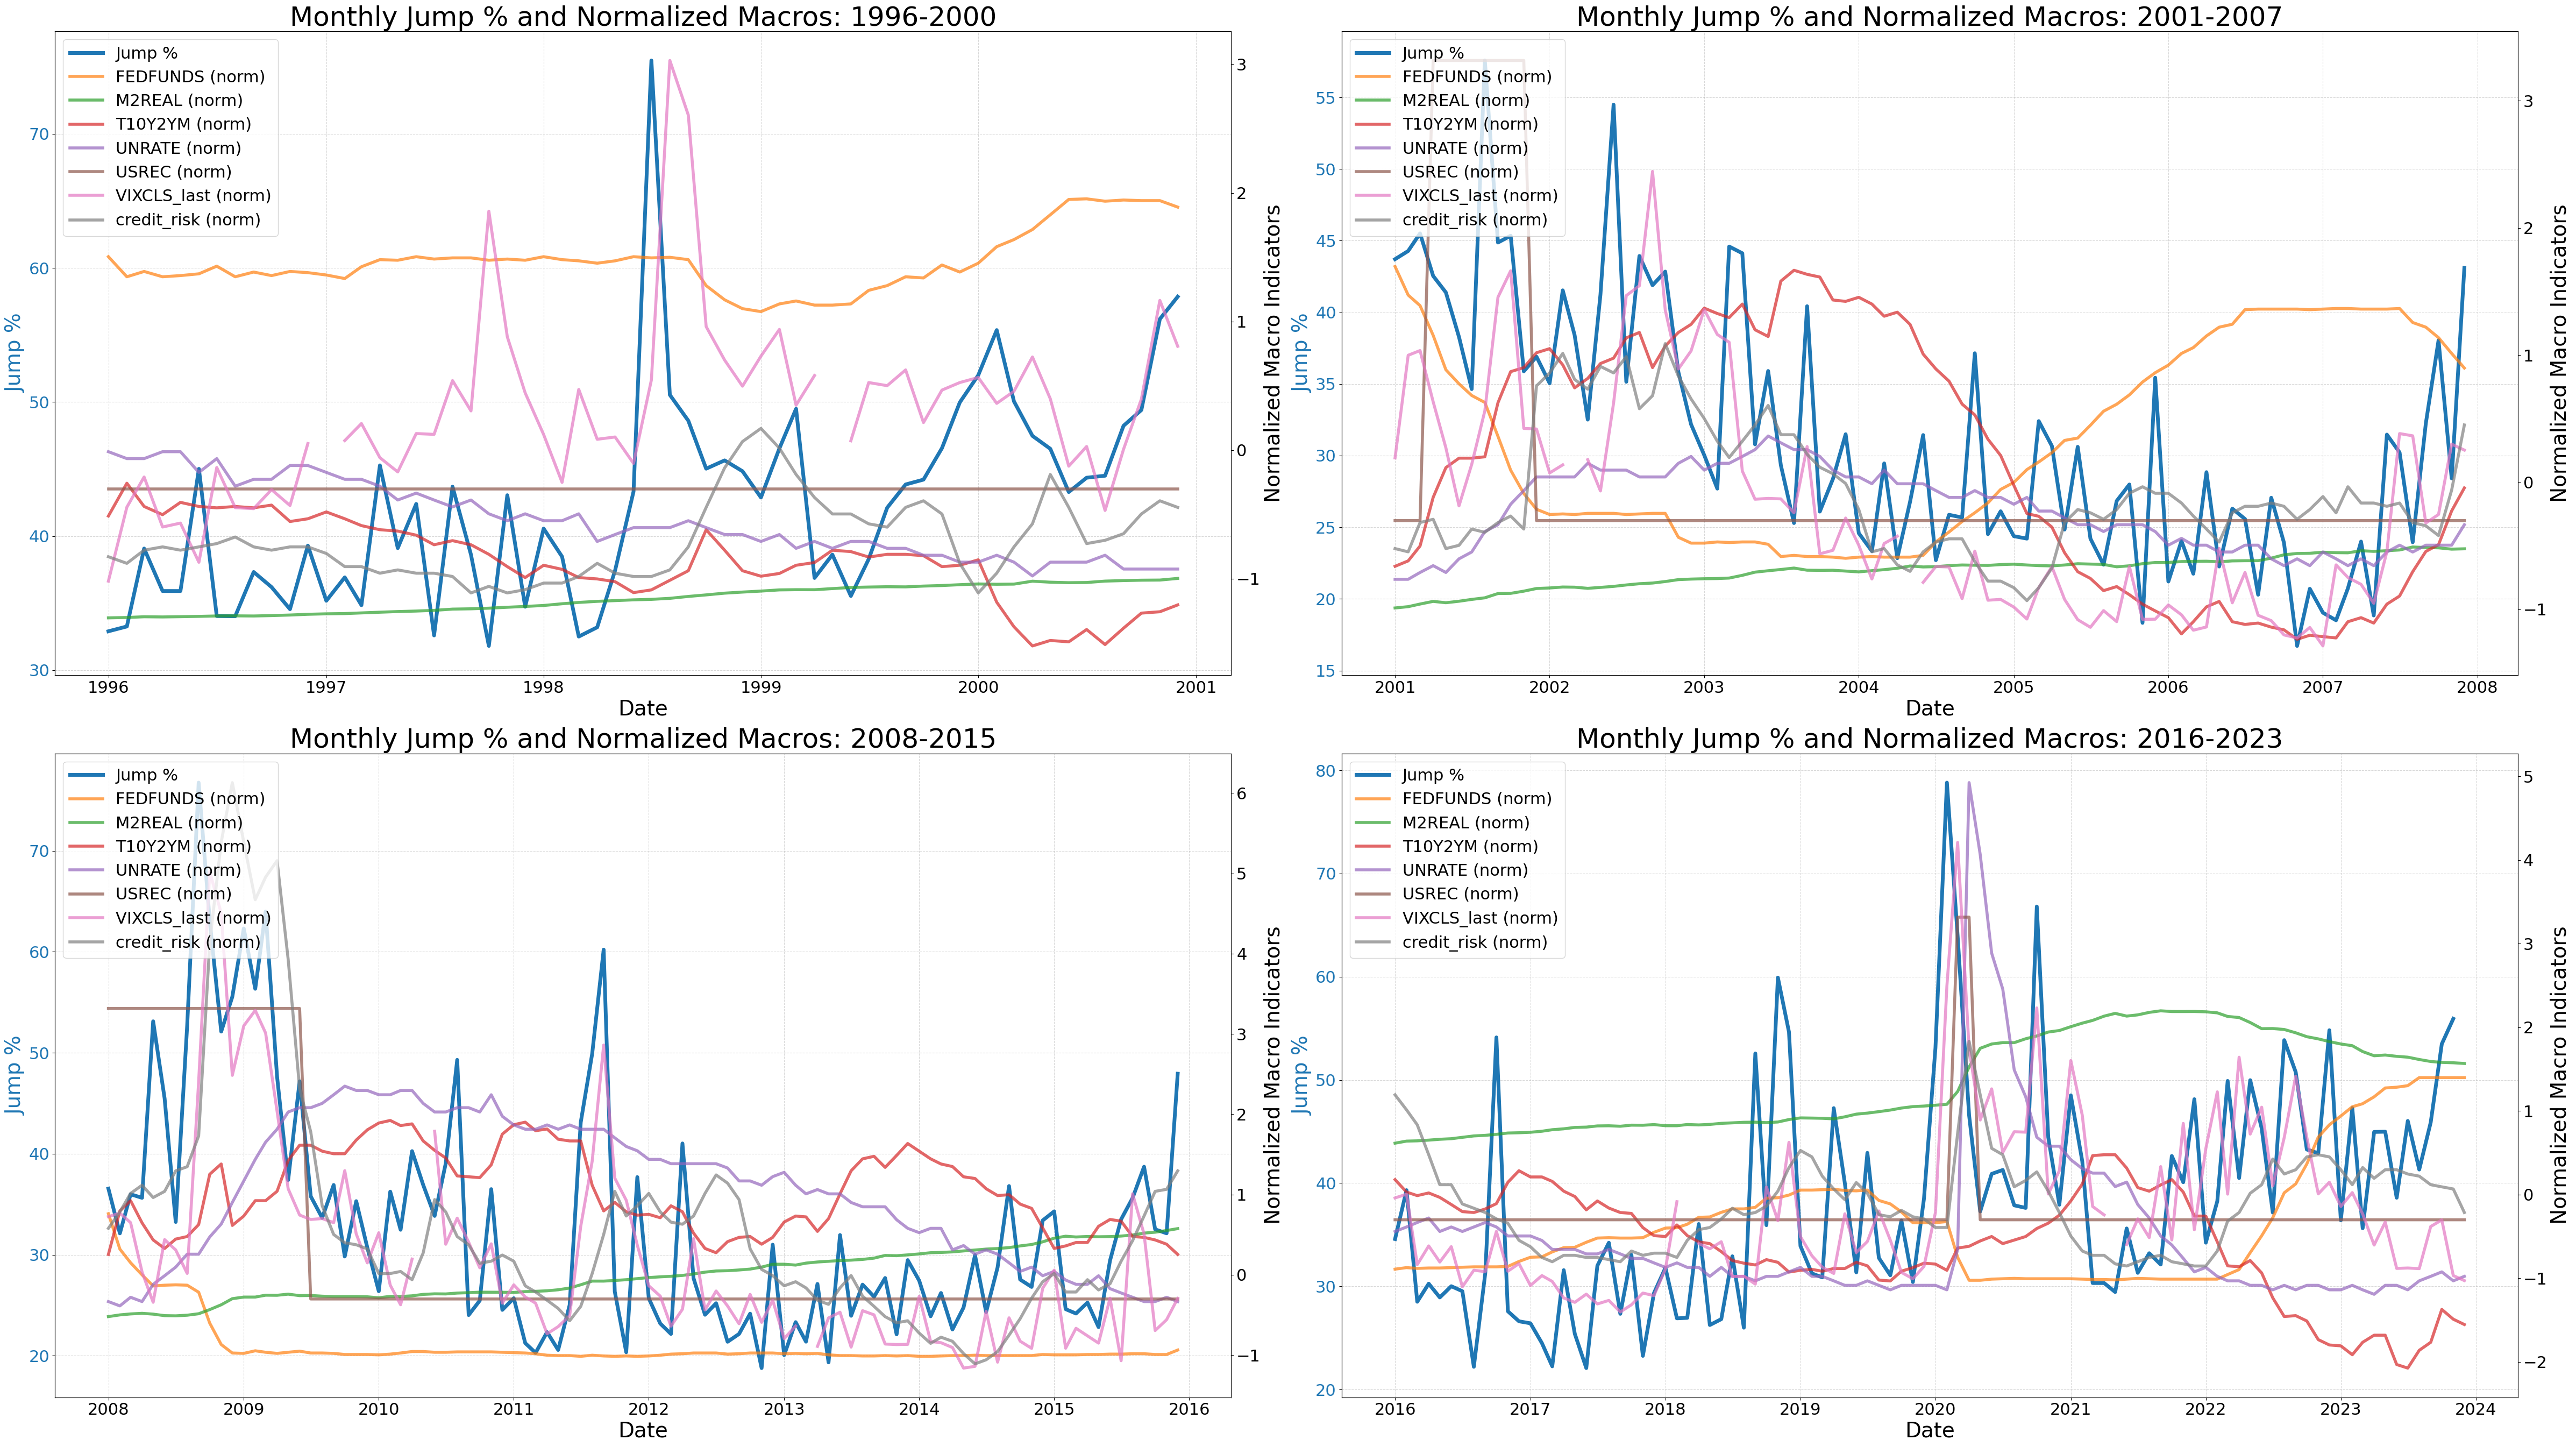

In [11]:
import matplotlib.pyplot as plt
import polars as pl
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Define the four time periods
periods = [
    (1996, 2000),
    (2001, 2007),
    (2008, 2015),
    (2016, 2023)
]

# Choose columns to plot (excluding year, month, total_jumps, n_obs)
indicator_cols = [col for col in monthly_jumps.columns if col not in ["year", "month", "total_jumps", "n_obs"]]

# Normalize macro indicators (excluding jump_pct) using polars
macro_cols = [col for col in indicator_cols if col != "jump_pct"]

# Extract macro columns as numpy for scaling
macro_np = monthly_jumps.select(macro_cols).to_numpy()
scaler = StandardScaler()
macro_scaled = scaler.fit_transform(macro_np)

# Create a new polars DataFrame with normalized macro columns
macro_scaled_df = pl.DataFrame(macro_scaled, schema=macro_cols)

# Add normalized macro columns to a copy of monthly_jumps
monthly_jumps_norm = monthly_jumps.with_columns([
    macro_scaled_df[col].alias(col) for col in macro_cols
])

# Convert to pandas for plotting (matplotlib expects pandas/numpy)
monthly_jumps_pd = monthly_jumps_norm.to_pandas()

# Create a 'date' column from 'year' and 'month'
monthly_jumps_pd["date"] = pd.to_datetime(
    monthly_jumps_pd["year"].astype(str) + "-" + monthly_jumps_pd["month"].astype(str).str.zfill(2) + "-01"
)

# Set up a 2x2 grid of subplots, large size
fig, axes = plt.subplots(2, 2, figsize=(32, 18), sharex=False)
axes = axes.flatten()

# Make the figure much bigger
fig.set_size_inches(48, 27)  # Increase figure size (was 32, 18)

for idx, (start_year, end_year) in enumerate(periods):
    ax = axes[idx]
    # Filter data for the period using year and month columns
    period_df = monthly_jumps_pd[
        (monthly_jumps_pd["year"] >= start_year) & (monthly_jumps_pd["year"] <= end_year)
    ].copy()
    # The 'date' column is already constructed from year and month
    # Plot jump_pct (primary y-axis)
    ax.plot(period_df["date"], period_df["jump_pct"], label="Jump %", color="tab:blue", linewidth=5)
    # Plot normalized macro indicators (secondary y-axis)
    ax2 = ax.twinx()
    colors = ["tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]
    color_idx = 0
    for col in macro_cols:
        ax2.plot(period_df["date"], period_df[col], label=col + " (norm)", color=colors[color_idx % len(colors)], linewidth=4, alpha=0.7)
        color_idx += 1
    # Set title and labels
    ax.set_title(f"Monthly Jump % and Normalized Macros: {start_year}-{end_year}", fontsize=36)
    ax.set_xlabel("Date", fontsize=28)
    ax.set_ylabel("Jump %", fontsize=28, color="tab:blue")
    ax.tick_params(axis='y', labelcolor="tab:blue", labelsize=22)
    ax.tick_params(axis='x', labelsize=22)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax2.set_ylabel("Normalized Macro Indicators", fontsize=28)
    ax2.tick_params(axis='y', labelsize=22)
    # Legends
    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels + labels2, loc="upper left", fontsize=22)

plt.tight_layout()
plt.show()


## Big shifts in VIXCLS influences the next months jump pct

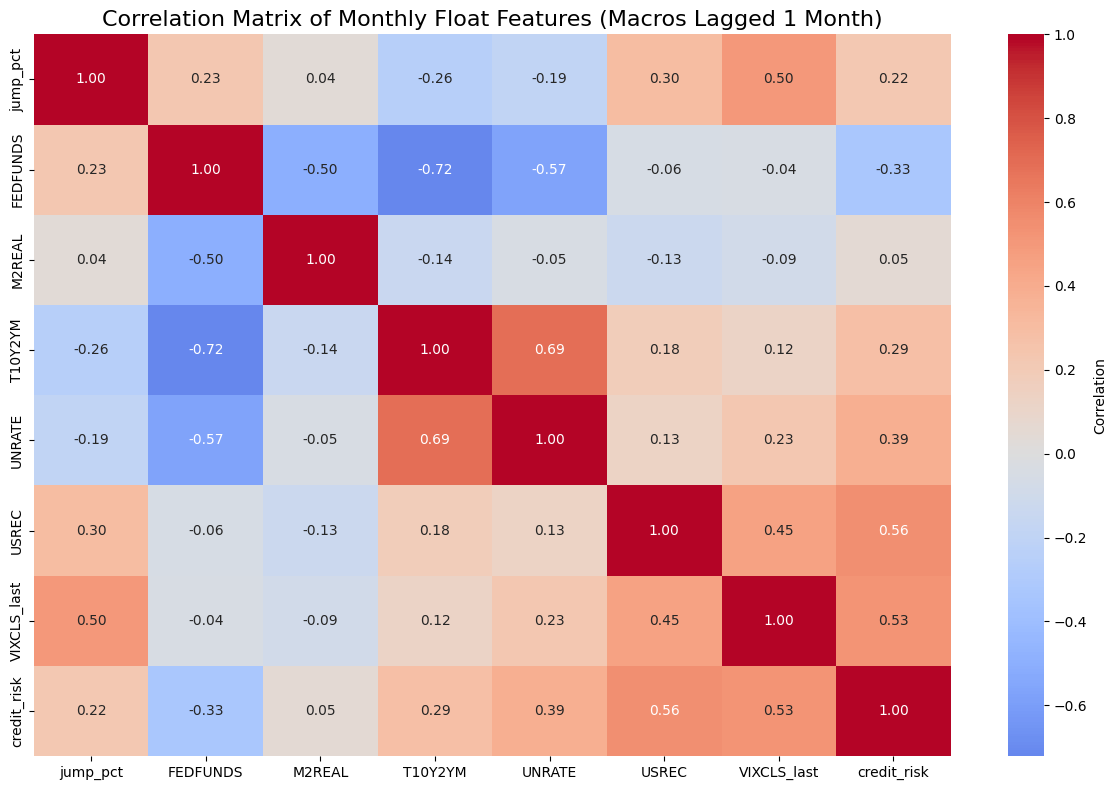

In [12]:
# Shift macro columns so that jump uses previous month's macros, then plot correlation matrix

import seaborn as sns

# Identify macro columns (all float columns except 'jump_pct' and any jump-related columns)
macro_cols = [col for col in monthly_jumps_pd.select_dtypes(include='float').columns if col not in ['jump_pct', 'jump', 'total_jumps', 'n_obs']]

# Shift macro columns by 1 so that each row's macro value is from the previous month
monthly_jumps_shifted = monthly_jumps_pd.copy()
for col in macro_cols:
    monthly_jumps_shifted[col] = monthly_jumps_shifted[col].shift(1)

# Optionally, you may want to drop the first row (since it will have NaNs after shifting)
monthly_jumps_shifted = monthly_jumps_shifted.dropna(subset=macro_cols)

# Select all float columns for correlation
float_cols = monthly_jumps_shifted.select_dtypes(include='float').columns.tolist()

# Compute correlation matrix
corr_matrix = monthly_jumps_shifted[float_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="coolwarm", 
    center=0, 
    cbar_kws={'label': 'Correlation'},
    fmt=".2f"
)
plt.title("Correlation Matrix of Monthly Float Features (Macros Lagged 1 Month)", fontsize=16)
plt.tight_layout()
plt.show()


In [13]:
# Count number of observations per PERMNO (firm)
firm_counts = df.group_by("PERMNO").count().select(["PERMNO", "count"])

# Get the top 100 PERMNOs with the most rows
top_100_permnos = (
    firm_counts.sort("count", descending=True)
    .head(100)
    .get_column("PERMNO")
    .to_list()
)

# Filter df to only those 100 firms
df_sampled = df.filter(pl.col("PERMNO").is_in(top_100_permnos))


C:\Users\jmani\AppData\Local\Temp\ipykernel_15652\1489686656.py:2: DeprecationWarning: `GroupBy.count` is deprecated. It has been renamed to `len`.
  firm_counts = df.group_by("PERMNO").count().select(["PERMNO", "count"])


In [14]:
df_sampled

PERMNO,date,SICCD,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,RETX,vwretd,year,month,industry,jump
i32,date,i32,str,str,i64,f64,i64,f64,i64,f64,f64,i32,i8,str,i8
10026,1996-01-31,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,12.0,5843,0.090909,9010,0.090909,0.028121,1996,1,"""Manufacturing""",0
10026,1996-02-29,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,11.875,5050,-0.010417,9010,-0.010417,0.016353,1996,2,"""Manufacturing""",0
10026,1996-03-29,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,11.875,8443,0.0,8930,0.0,0.010914,1996,3,"""Manufacturing""",0
10026,1996-04-30,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,12.25,4696,0.031579,8930,0.031579,0.02556,1996,4,"""Manufacturing""",0
10026,1996-05-31,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,13.125,5489,0.071429,8930,0.071429,0.02681,1996,5,"""Manufacturing""",1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11955,2023-08-31,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,156.78,284932,-0.042799,405059,-0.042799,-0.020605,2023,8,"""Transportation""",0
11955,2023-09-29,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,152.44,283758,-0.023217,405059,-0.027682,-0.04739,2023,9,"""Transportation""",0
11955,2023-10-31,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,164.33,360919,0.077998,402775,0.077998,-0.028867,2023,10,"""Transportation""",0


In [15]:
import numpy as np
from sklearn.linear_model import LinearRegression

df_sampled = df_sampled.sort(["PERMNO", "date"])

def compute_rolling_beta(pdf):
    # Ensure sorted by date
    pdf = pdf.sort("date")
    # Prepare arrays for output
    betas = [None] * len(pdf)
    idio_vols = [None] * len(pdf)
    market_vols = [None] * len(pdf)
    # Only start from 1997
    for i in range(len(pdf)):
        if pdf[i, "date"].year < 1997:
            continue
        # Lookback window: previous 12 months (including current) - to capture short term relations
        window = pdf[max(0, i-11):i+1]
        # Drop rows with nulls in RETX or vwretd
        window = window.filter(
            pl.col("RETX").is_not_null() & pl.col("vwretd").is_not_null()
        )
        if window.height < 12:
            continue  # Require full 6 months
        X = window["vwretd"].to_numpy().reshape(-1, 1)
        y = window["RETX"].to_numpy()
        if np.isnan(X).any() or np.isnan(y).any():
            continue
        reg = LinearRegression().fit(X, y)
        betas[i] = reg.coef_[0]

    # Compute rolling  volatility (standard deviation of RETX over last 6 months)
    for i in range(len(pdf)):
        if pdf[i, "date"].year < 1997:
            continue
        # Lookback window: previous 6 months (including current)
        window6 = pdf[max(0, i-5):i+1]
        # Drop rows with nulls in RETX
        window6 = window6.filter(pl.col("RETX").is_not_null())
        if window6.height < 6:
            continue  # Require full 6 months
        rets = window6["RETX"].to_numpy()
        if np.isnan(rets).any():
            continue
        idio_vols[i] = np.std(rets, ddof=1)
    
    for i in range(len(pdf)):
        if pdf[i, "date"].year < 1997:
            continue
        # Lookback window: previous 6 months (including current)
        window6 = pdf[max(0, i-5):i+1]
        # Drop rows with nulls in RETX
        window6 = window6.filter(pl.col("RETX").is_not_null())
        if window6.height < 6:
            continue  # Require full 6 months
        rets = window6["vwretd"].to_numpy()
        if np.isnan(rets).any():
            continue
        market_vols[i] = np.std(rets, ddof=1)

    return pdf.with_columns([
        pl.Series("beta", betas),
        pl.Series("return_vol_6months", idio_vols),
        pl.Series("universe_vol_6months",market_vols)
    ])

dfs = []
for group in df_sampled.group_by("PERMNO", maintain_order=True):
    pdf = group[1]
    dfs.append(compute_rolling_beta(pdf))
df_with_beta = pl.concat(dfs)

df_with_beta


PERMNO,date,SICCD,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,RETX,vwretd,year,month,industry,jump,beta,return_vol_6months,universe_vol_6months
i32,date,i32,str,str,i64,f64,i64,f64,i64,f64,f64,i32,i8,str,i8,f64,f64,f64
10026,1996-01-31,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,12.0,5843,0.090909,9010,0.090909,0.028121,1996,1,"""Manufacturing""",0,null,null,null
10026,1996-02-29,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,11.875,5050,-0.010417,9010,-0.010417,0.016353,1996,2,"""Manufacturing""",0,null,null,null
10026,1996-03-29,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,11.875,8443,0.0,8930,0.0,0.010914,1996,3,"""Manufacturing""",0,null,null,null
10026,1996-04-30,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,12.25,4696,0.031579,8930,0.031579,0.02556,1996,4,"""Manufacturing""",0,null,null,null
10026,1996-05-31,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,13.125,5489,0.071429,8930,0.071429,0.02681,1996,5,"""Manufacturing""",1,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11955,2023-08-31,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,156.78,284932,-0.042799,405059,-0.042799,-0.020605,2023,8,"""Transportation""",0,0.548689,0.060668,0.030102
11955,2023-09-29,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,152.44,283758,-0.023217,405059,-0.027682,-0.04739,2023,9,"""Transportation""",0,0.565151,0.046928,0.040213
11955,2023-10-31,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,164.33,360919,0.077998,402775,0.077998,-0.028867,2023,10,"""Transportation""",0,0.531418,0.059038,0.042774


In [16]:
df_with_beta = df_with_beta.filter(
    pl.col("beta").is_not_null() & pl.col("jump").is_not_null() 
)


In [17]:
df_with_beta

PERMNO,date,SICCD,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,RETX,vwretd,year,month,industry,jump,beta,return_vol_6months,universe_vol_6months
i32,date,i32,str,str,i64,f64,i64,f64,i64,f64,f64,i32,i8,str,i8,f64,f64,f64
10026,1997-01-31,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,13.0,4664,-0.037037,8750,-0.037037,0.053473,1997,1,"""Manufacturing""",0,0.501825,0.093782,0.029023
10026,1997-02-28,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,12.9375,3664,-0.004808,8750,-0.004808,-0.001067,1997,2,"""Manufacturing""",0,0.508115,0.094784,0.032505
10026,1997-03-31,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,12.75,2567,-0.014493,8767,-0.014493,-0.044889,1997,3,"""Manufacturing""",0,0.484198,0.097482,0.041345
10026,1997-04-30,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,12.75,4263,0.0,8767,0.0,0.042396,1997,4,"""Manufacturing""",1,0.431879,0.098375,0.043123
10026,1997-05-30,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,14.25,3357,0.117647,8767,0.117647,0.07164,1997,5,"""Manufacturing""",0,0.641987,0.103169,0.044524
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11955,2023-07-31,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,163.78999,312725,-0.05553,405059,-0.05553,0.035624,2023,7,"""Transportation""",0,0.444554,0.058972,0.0312
11955,2023-08-31,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,156.78,284932,-0.042799,405059,-0.042799,-0.020605,2023,8,"""Transportation""",0,0.548689,0.060668,0.030102
11955,2023-09-29,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,152.44,283758,-0.023217,405059,-0.027682,-0.04739,2023,9,"""Transportation""",0,0.565151,0.046928,0.040213


In [18]:
df_with_beta = df_with_beta.join(macro_big, on=["year", "month"], how="left")


In [19]:
df_with_beta

PERMNO,date,SICCD,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,RETX,vwretd,year,month,industry,jump,beta,return_vol_6months,universe_vol_6months,AAA,BAA,FEDFUNDS,M2REAL,T10Y2YM,UNRATE,USREC,VIXCLS_last,credit_risk
i32,date,i32,str,str,i64,f64,i64,f64,i64,f64,f64,i32,i8,str,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64
10026,1997-01-31,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,13.0,4664,-0.037037,8750,-0.037037,0.053473,1997,1,"""Manufacturing""",0,0.501825,0.093782,0.029023,7.42,8.09,5.25,2405.6,0.57,5.3,0,null,0.67
10026,1997-02-28,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,12.9375,3664,-0.004808,8750,-0.004808,-0.001067,1997,2,"""Manufacturing""",0,0.508115,0.094784,0.032505,7.31,7.94,5.19,2408.5,0.52,5.2,0,21.1,0.63
10026,1997-03-31,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,12.75,2567,-0.014493,8767,-0.014493,-0.044889,1997,3,"""Manufacturing""",0,0.484198,0.097482,0.041345,7.55,8.18,5.39,2416.3,0.47,5.2,0,22.14,0.63
10026,1997-04-30,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,12.75,4263,0.0,8767,0.0,0.042396,1997,4,"""Manufacturing""",1,0.431879,0.098375,0.043123,7.73,8.34,5.51,2424.6,0.44,5.1,0,20.06,0.61
10026,1997-05-30,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,14.25,3357,0.117647,8767,0.117647,0.07164,1997,5,"""Manufacturing""",0,0.641987,0.103169,0.044524,7.58,8.2,5.5,2432.3,0.43,4.9,0,19.19,0.62
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11955,2023-07-31,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,163.78999,312725,-0.05553,405059,-0.05553,0.035624,2023,7,"""Transportation""",0,0.444554,0.058972,0.0312,4.66,5.74,5.12,6819.1,-0.93,3.5,0,13.63,1.08
11955,2023-08-31,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,156.78,284932,-0.042799,405059,-0.042799,-0.020605,2023,8,"""Transportation""",0,0.548689,0.060668,0.030102,4.95,6.02,5.33,6777.0,-0.73,3.7,0,13.57,1.07
11955,2023-09-29,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,152.44,283758,-0.023217,405059,-0.027682,-0.04739,2023,9,"""Transportation""",0,0.565151,0.046928,0.040213,5.13,6.16,5.33,6741.1,-0.64,3.8,0,17.52,1.03


In [20]:
df_with_beta = df_with_beta.drop(["AAA", "BAA"])
df_with_beta



PERMNO,date,SICCD,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,RETX,vwretd,year,month,industry,jump,beta,return_vol_6months,universe_vol_6months,FEDFUNDS,M2REAL,T10Y2YM,UNRATE,USREC,VIXCLS_last,credit_risk
i32,date,i32,str,str,i64,f64,i64,f64,i64,f64,f64,i32,i8,str,i8,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64
10026,1997-01-31,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,13.0,4664,-0.037037,8750,-0.037037,0.053473,1997,1,"""Manufacturing""",0,0.501825,0.093782,0.029023,5.25,2405.6,0.57,5.3,0,null,0.67
10026,1997-02-28,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,12.9375,3664,-0.004808,8750,-0.004808,-0.001067,1997,2,"""Manufacturing""",0,0.508115,0.094784,0.032505,5.19,2408.5,0.52,5.2,0,21.1,0.63
10026,1997-03-31,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,12.75,2567,-0.014493,8767,-0.014493,-0.044889,1997,3,"""Manufacturing""",0,0.484198,0.097482,0.041345,5.39,2416.3,0.47,5.2,0,22.14,0.63
10026,1997-04-30,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,12.75,4263,0.0,8767,0.0,0.042396,1997,4,"""Manufacturing""",1,0.431879,0.098375,0.043123,5.51,2424.6,0.44,5.1,0,20.06,0.61
10026,1997-05-30,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,14.25,3357,0.117647,8767,0.117647,0.07164,1997,5,"""Manufacturing""",0,0.641987,0.103169,0.044524,5.5,2432.3,0.43,4.9,0,19.19,0.62
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11955,2023-07-31,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,163.78999,312725,-0.05553,405059,-0.05553,0.035624,2023,7,"""Transportation""",0,0.444554,0.058972,0.0312,5.12,6819.1,-0.93,3.5,0,13.63,1.08
11955,2023-08-31,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,156.78,284932,-0.042799,405059,-0.042799,-0.020605,2023,8,"""Transportation""",0,0.548689,0.060668,0.030102,5.33,6777.0,-0.73,3.7,0,13.57,1.07
11955,2023-09-29,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,152.44,283758,-0.023217,405059,-0.027682,-0.04739,2023,9,"""Transportation""",0,0.565151,0.046928,0.040213,5.33,6741.1,-0.64,3.8,0,17.52,1.03


In [21]:
cols_to_shift = ['beta','return_vol_6months','universe_vol_6months',"PRC", "VOL", "SHROUT", "RETX", "vwretd","idio_vol","UNRATE","FEDFUNDS",'M2REAL','T10Y2M','credit_risk','USREC']
for col in cols_to_shift:
    if col in df_with_beta.columns:
        df_with_beta = df_with_beta.with_columns(
            pl.col(col).shift(1).alias(f"{col}_prev")
        )


In [22]:
df_with_beta = df_with_beta.drop_nulls()

In [23]:
df_with_beta

PERMNO,date,SICCD,TICKER,COMNAM,PERMCO,PRC,VOL,RET,SHROUT,RETX,vwretd,year,month,industry,jump,beta,return_vol_6months,universe_vol_6months,FEDFUNDS,M2REAL,T10Y2YM,UNRATE,USREC,VIXCLS_last,credit_risk,beta_prev,return_vol_6months_prev,universe_vol_6months_prev,PRC_prev,VOL_prev,SHROUT_prev,RETX_prev,vwretd_prev,UNRATE_prev,FEDFUNDS_prev,M2REAL_prev,credit_risk_prev,USREC_prev
i32,date,i32,str,str,i64,f64,i64,f64,i64,f64,f64,i32,i8,str,i8,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,i64
10026,1997-02-28,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,12.9375,3664,-0.004808,8750,-0.004808,-0.001067,1997,2,"""Manufacturing""",0,0.508115,0.094784,0.032505,5.19,2408.5,0.52,5.2,0,21.1,0.63,0.501825,0.093782,0.029023,13.0,4664,8750,-0.037037,0.053473,5.3,5.25,2405.6,0.67,0
10026,1997-03-31,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,12.75,2567,-0.014493,8767,-0.014493,-0.044889,1997,3,"""Manufacturing""",0,0.484198,0.097482,0.041345,5.39,2416.3,0.47,5.2,0,22.14,0.63,0.508115,0.094784,0.032505,12.9375,3664,8750,-0.004808,-0.001067,5.2,5.19,2408.5,0.63,0
10026,1997-04-30,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,12.75,4263,0.0,8767,0.0,0.042396,1997,4,"""Manufacturing""",1,0.431879,0.098375,0.043123,5.51,2424.6,0.44,5.1,0,20.06,0.61,0.484198,0.097482,0.041345,12.75,2567,8767,-0.014493,-0.044889,5.2,5.39,2416.3,0.63,0
10026,1997-05-30,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,14.25,3357,0.117647,8767,0.117647,0.07164,1997,5,"""Manufacturing""",0,0.641987,0.103169,0.044524,5.5,2432.3,0.43,4.9,0,19.19,0.62,0.431879,0.098375,0.043123,12.75,4263,8767,0.0,0.042396,5.1,5.51,2424.6,0.61,0
10026,1997-06-30,2050,"""JJSF""","""J & J SNACK FOODS CORP""",7976,15.375,4784,0.078947,8797,0.078947,0.044081,1997,6,"""Manufacturing""",0,0.514737,0.060663,0.042839,5.56,2438.2,0.4,5.0,0,21.53,0.61,0.641987,0.103169,0.044524,14.25,3357,8767,0.117647,0.07164,4.9,5.5,2432.3,0.62,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11955,2023-07-31,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,163.78999,312725,-0.05553,405059,-0.05553,0.035624,2023,7,"""Transportation""",0,0.444554,0.058972,0.0312,5.12,6819.1,-0.93,3.5,0,13.63,1.08,0.55929,0.051546,0.037952,173.42,292570,406817,0.071023,0.066183,3.6,5.08,6834.2,1.1,0
11955,2023-08-31,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,156.78,284932,-0.042799,405059,-0.042799,-0.020605,2023,8,"""Transportation""",0,0.548689,0.060668,0.030102,5.33,6777.0,-0.73,3.7,0,13.57,1.07,0.444554,0.058972,0.0312,163.78999,312725,405059,-0.05553,0.035624,3.5,5.12,6819.1,1.08,0
11955,2023-09-29,4953,"""WM""","""WASTE MANAGEMENT INC DEL""",9804,152.44,283758,-0.023217,405059,-0.027682,-0.04739,2023,9,"""Transportation""",0,0.565151,0.046928,0.040213,5.33,6741.1,-0.64,3.8,0,17.52,1.03,0.548689,0.060668,0.030102,156.78,284932,405059,-0.042799,-0.020605,3.7,5.33,6777.0,1.07,0


In [24]:

float_cols = [col for col, dtype in zip(df_with_beta.columns, df_with_beta.dtypes) if dtype == pl.Float64]
cols_to_keep = []
for col in df_with_beta.columns:
    
    if col in float_cols:
        if col.endswith("_prev") or col in ['VIXCLS_last']:
            cols_to_keep.append(col)
    # For non-float columns, only keep if not in drop list and not a float col
    elif col not in ["date",'PERMCO','TICKER', 'COMNAM','VOL', 'SHROUT','USREC','SICCD']:
        cols_to_keep.append(col)
dataset = df_with_beta.select(cols_to_keep)

dataset

PERMNO,year,month,industry,jump,VIXCLS_last,beta_prev,return_vol_6months_prev,universe_vol_6months_prev,PRC_prev,VOL_prev,SHROUT_prev,RETX_prev,vwretd_prev,UNRATE_prev,FEDFUNDS_prev,M2REAL_prev,credit_risk_prev,USREC_prev
i32,i32,i8,str,i8,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,i64
10026,1997,2,"""Manufacturing""",0,21.1,0.501825,0.093782,0.029023,13.0,4664,8750,-0.037037,0.053473,5.3,5.25,2405.6,0.67,0
10026,1997,3,"""Manufacturing""",0,22.14,0.508115,0.094784,0.032505,12.9375,3664,8750,-0.004808,-0.001067,5.2,5.19,2408.5,0.63,0
10026,1997,4,"""Manufacturing""",1,20.06,0.484198,0.097482,0.041345,12.75,2567,8767,-0.014493,-0.044889,5.2,5.39,2416.3,0.63,0
10026,1997,5,"""Manufacturing""",0,19.19,0.431879,0.098375,0.043123,12.75,4263,8767,0.0,0.042396,5.1,5.51,2424.6,0.61,0
10026,1997,6,"""Manufacturing""",0,21.53,0.641987,0.103169,0.044524,14.25,3357,8767,0.117647,0.07164,4.9,5.5,2432.3,0.62,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11955,2023,7,"""Transportation""",0,13.63,0.55929,0.051546,0.037952,173.42,292570,406817,0.071023,0.066183,3.6,5.08,6834.2,1.1,0
11955,2023,8,"""Transportation""",0,13.57,0.444554,0.058972,0.0312,163.78999,312725,405059,-0.05553,0.035624,3.5,5.12,6819.1,1.08,0
11955,2023,9,"""Transportation""",0,17.52,0.548689,0.060668,0.030102,156.78,284932,405059,-0.042799,-0.020605,3.7,5.33,6777.0,1.07,0


In [ ]:

if "industry" in dataset.columns:
    dataset = dataset.with_columns(
        pl.col("industry").rank(method="dense").cast(pl.Int32).alias("SICCD_encoded")
    )
    dataset = dataset.drop("industry")


In [26]:
dataset

PERMNO,year,month,jump,VIXCLS_last,beta_prev,return_vol_6months_prev,universe_vol_6months_prev,PRC_prev,VOL_prev,SHROUT_prev,RETX_prev,vwretd_prev,UNRATE_prev,FEDFUNDS_prev,M2REAL_prev,credit_risk_prev,USREC_prev,SICCD_encoded
i32,i32,i8,i8,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i32
10026,1997,2,0,21.1,0.501825,0.093782,0.029023,13.0,4664,8750,-0.037037,0.053473,5.3,5.25,2405.6,0.67,0,3
10026,1997,3,0,22.14,0.508115,0.094784,0.032505,12.9375,3664,8750,-0.004808,-0.001067,5.2,5.19,2408.5,0.63,0,3
10026,1997,4,1,20.06,0.484198,0.097482,0.041345,12.75,2567,8767,-0.014493,-0.044889,5.2,5.39,2416.3,0.63,0,3
10026,1997,5,0,19.19,0.431879,0.098375,0.043123,12.75,4263,8767,0.0,0.042396,5.1,5.51,2424.6,0.61,0,3
10026,1997,6,0,21.53,0.641987,0.103169,0.044524,14.25,3357,8767,0.117647,0.07164,4.9,5.5,2432.3,0.62,0,3
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11955,2023,7,0,13.63,0.55929,0.051546,0.037952,173.42,292570,406817,0.071023,0.066183,3.6,5.08,6834.2,1.1,0,8
11955,2023,8,0,13.57,0.444554,0.058972,0.0312,163.78999,312725,405059,-0.05553,0.035624,3.5,5.12,6819.1,1.08,0,8
11955,2023,9,0,17.52,0.548689,0.060668,0.030102,156.78,284932,405059,-0.042799,-0.020605,3.7,5.33,6777.0,1.07,0,8


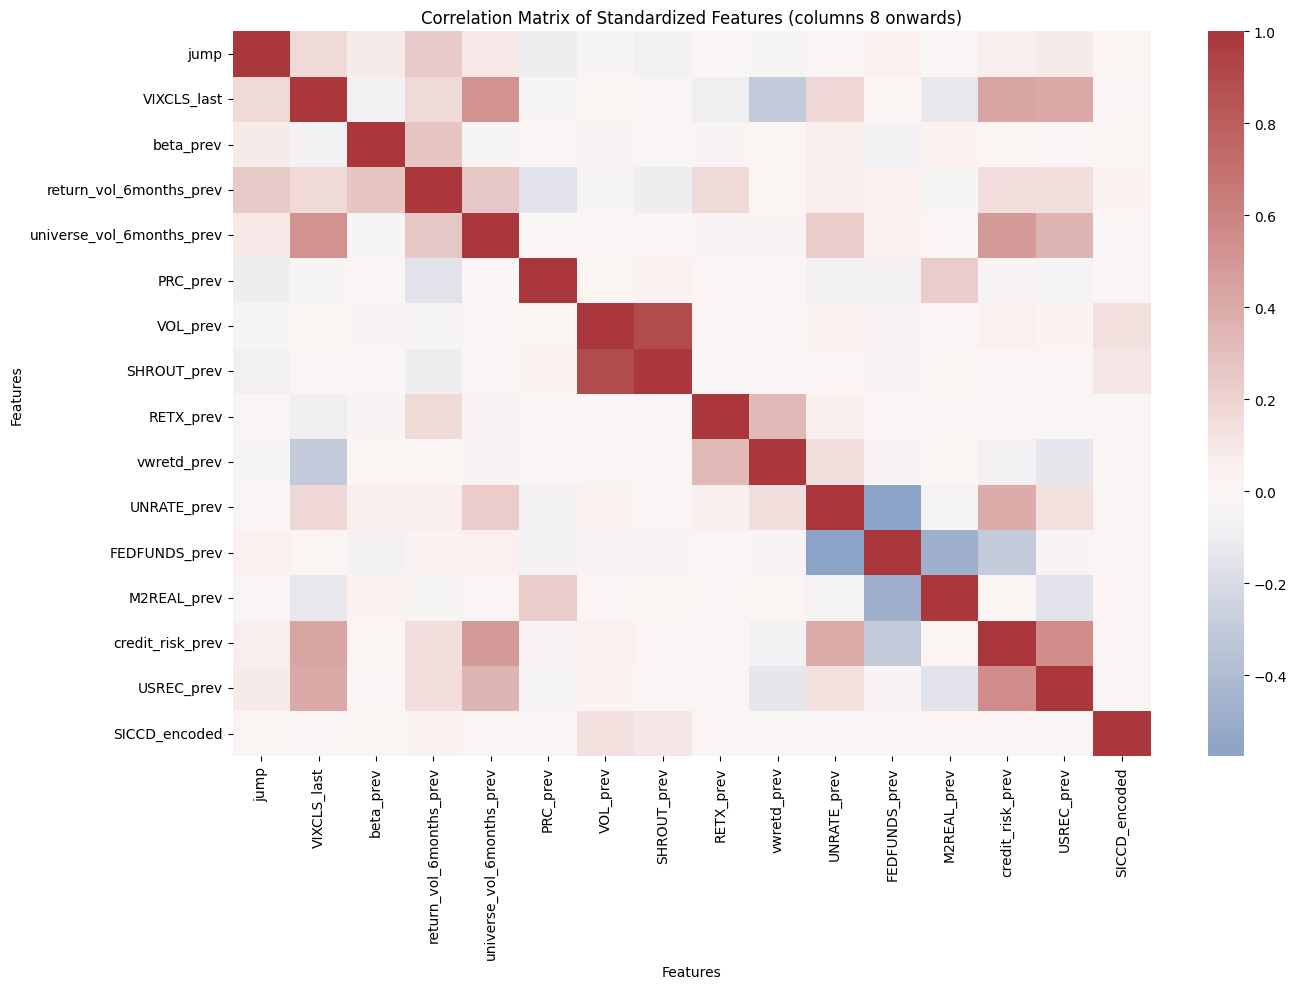

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

df_plot = dataset.to_pandas()

cols_to_scale = df_plot.columns[4:]
scaler = MinMaxScaler(feature_range=(0, 1))
df_plot_standardized = df_plot.copy()
df_plot_standardized[cols_to_scale] = scaler.fit_transform(df_plot[cols_to_scale])

cols_for_corr = list(cols_to_scale)
if 'jump' in df_plot_standardized.columns:
    cols_for_corr = ['jump'] + [col for col in cols_for_corr if col != 'jump']
corr_matrix = df_plot_standardized[cols_for_corr].corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='vlag', center=0, annot=False, fmt=".2f", cbar=True)
plt.title("Correlation Matrix of Standardized Features (columns 8 onwards)")
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()
plt.show()


## On their own no strong predictors have to transform them

In [28]:

dataset = dataset.sort(["PERMNO", "year", "month"]) 

numeric_cols = [
    "RETX_prev",
    "PRC_prev",
    "VOL_prev"
]

windows = [ 3, 6, 12]

zscore_exprs = []

for col in numeric_cols:
    for w in windows:
        # rolling mean and std
        rolling_mean = pl.col(col).rolling_mean(window_size=w, min_periods=1).over("PERMNO")
        rolling_std = pl.col(col).rolling_std(window_size=w, min_periods=1).over("PERMNO")
        
        # safe z-score: divide by std only if > 0, else return 0
        safe_std = pl.when(rolling_std > 0).then(rolling_std).otherwise(1)
        zscore_exprs += [
            ((pl.col(col) - rolling_mean) / safe_std).alias(f"{col}_z_{w}m")
        ]

# Key interactions and derived features
zscore_exprs += [
    (pl.col("RETX_prev") - pl.col("vwretd_prev")).alias("excess_return_prev"),
    (pl.col("beta_prev") * pl.col("VIXCLS_last")).alias("beta_VIX_interaction"),
    (pl.col("VOL_prev") * pl.col("PRC_prev")).alias("dollar_trading_vol_prev"),
]

dataset = dataset.with_columns(zscore_exprs)



In [29]:
dataset = dataset.drop_nulls()
dataset = dataset.sort(["year", "month"])
dataset

PERMNO,year,month,jump,VIXCLS_last,beta_prev,return_vol_6months_prev,universe_vol_6months_prev,PRC_prev,VOL_prev,SHROUT_prev,RETX_prev,vwretd_prev,UNRATE_prev,FEDFUNDS_prev,M2REAL_prev,credit_risk_prev,USREC_prev,SICCD_encoded,RETX_prev_z_3m,RETX_prev_z_6m,RETX_prev_z_12m,PRC_prev_z_3m,PRC_prev_z_6m,PRC_prev_z_12m,VOL_prev_z_3m,VOL_prev_z_6m,VOL_prev_z_12m,excess_return_prev,beta_VIX_interaction,dollar_trading_vol_prev
i32,i32,i8,i8,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,f64,f64,i64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
11600,1997,2,0,21.1,0.97629,0.063878,0.029023,49.75,25483,26900,0.047368,0.053473,5.3,5.25,2405.6,0.67,0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.006105,20.59971,1.2678e6
10032,1997,2,0,21.1,3.786803,0.355025,0.029023,31.75,35160,6544,0.895522,0.053473,5.3,5.25,2405.6,0.67,0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.842049,79.90155,1.11633e6
10257,1997,2,1,21.1,2.219128,0.221797,0.029023,3.23438,22908,19080,-0.059091,0.053473,5.3,5.25,2405.6,0.67,0,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.112564,46.823605,74093.17704
11731,1997,2,0,21.1,0.945549,0.040033,0.029023,23.5,10928,24796,0.016216,0.053473,5.3,5.25,2405.6,0.67,0,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.037257,19.951092,256808.0
10696,1997,2,1,21.1,-0.384377,0.071956,0.029023,33.4375,61921,45348,-0.090136,0.053473,5.3,5.25,2405.6,0.67,0,7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.143609,-8.110363,2.0705e6
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
11397,2023,11,1,12.92,0.75444,0.126541,0.042774,23.19,24120,17031,-0.119256,-0.028867,3.9,5.33,6724.3,1.02,0,2,-0.473951,-0.743594,-0.603913,-1.085109,-1.276321,-1.155578,1.09372,-0.318998,0.081968,-0.090389,9.747366,559342.8
11275,2023,11,0,12.92,-0.112401,0.111078,0.042774,2.27,10845,45639,-0.159259,-0.028867,3.9,5.33,6724.3,1.02,0,3,-1.147664,-0.524246,-1.1198,-1.136901,-1.124493,-1.506717,-0.54314,-0.538021,-0.286919,-0.130392,-1.452223,24618.15
11884,2023,11,1,12.92,1.858141,0.101913,0.042774,127.11,22861,31981,-0.053819,-0.028867,3.9,5.33,6724.3,1.02,0,9,-0.081753,-0.28602,-0.837212,-1.044905,-0.928901,-0.048812,0.049507,-0.54184,-0.388372,-0.024952,24.007183,2.9059e6


In [30]:
jump_percentage = dataset["jump"].mean() * 100
print(f"Percentage of jumps in dataset: {jump_percentage:.2f}%")


Percentage of jumps in dataset: 29.72%


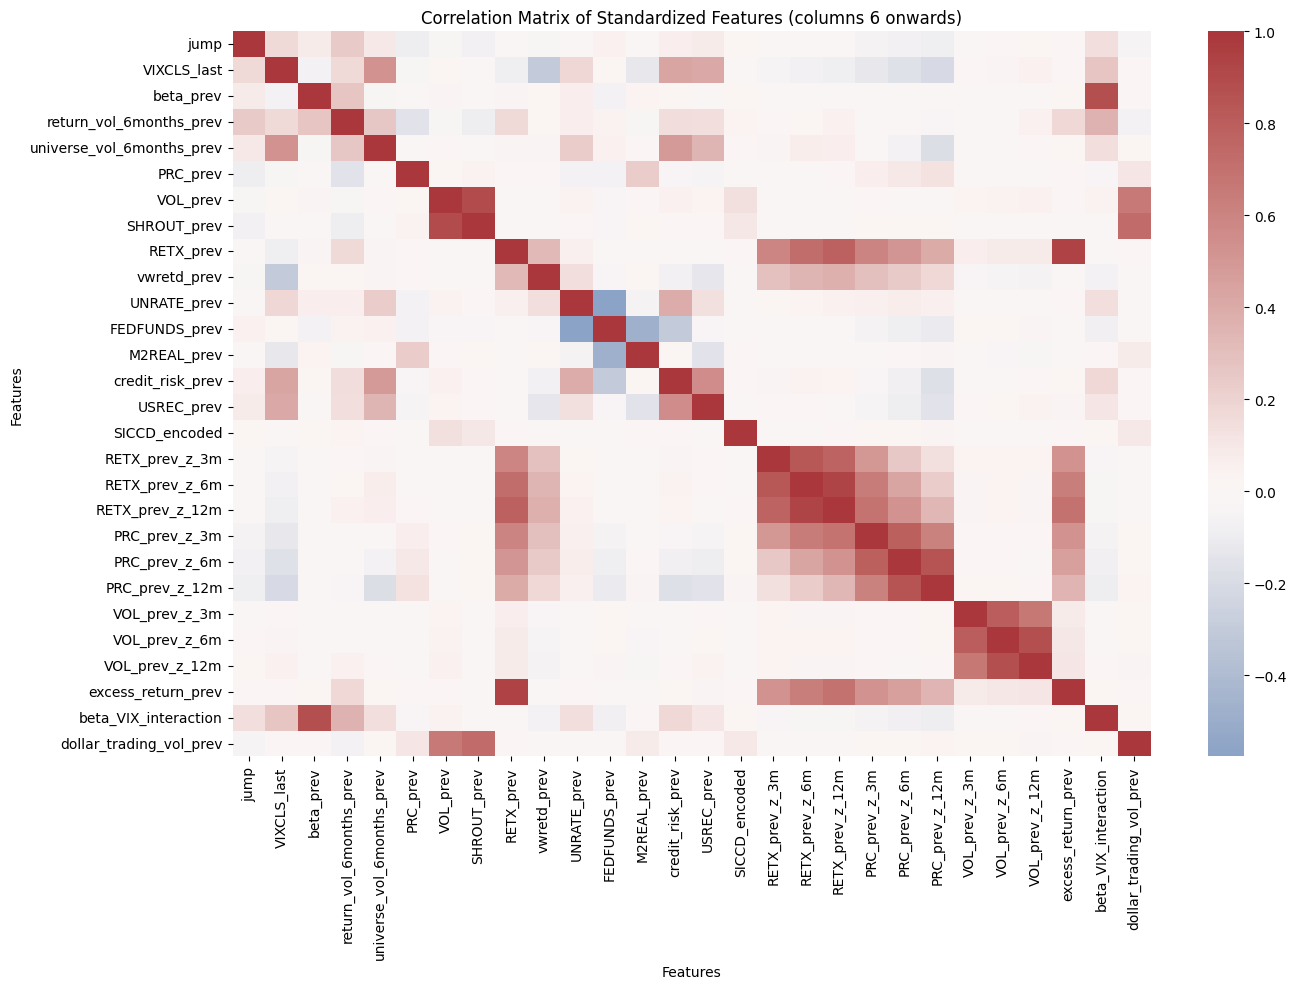

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

df_plot = dataset.to_pandas()


cols_to_standardize = df_plot.columns[3:]
scaler = StandardScaler()
df_plot_standardized = df_plot.copy()
df_plot_standardized[cols_to_standardize] = scaler.fit_transform(df_plot[cols_to_standardize])

corr_matrix = df_plot_standardized[cols_to_standardize].corr()


plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='vlag', center=0, annot=False, fmt=".2f", cbar=True)
plt.title("Correlation Matrix of Standardized Features (columns 6 onwards)")
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## Logistic Regression

In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from scipy.stats import ks_2samp

def prepare_datasets(dataset, target_col="jump", start_year=1996, train_end_year=2017, test_start_year=2018):
    
    # Identify feature columns
    all_columns = dataset.columns
    exclude = {"PERMNO", "date", "SICCD", "TICKER", "year", "month", "jump", "COMNAM", "PERMCO"}
    feature_columns = [col for col in all_columns if col not in exclude and col != target_col]

    # 1. Fixed split: up to 2017 train, 2018+ test
    train_df = dataset.filter(pl.col("year") <= train_end_year)
    test_df = dataset.filter(pl.col("year") >= test_start_year)
    X_train_fixed = train_df.select(feature_columns).to_numpy()
    y_train_fixed = train_df[target_col].to_numpy()
    X_test_fixed = test_df.select(feature_columns).to_numpy()
    y_test_fixed = test_df[target_col].to_numpy()
    scaler_fixed = StandardScaler()
    X_train_fixed_scaled = scaler_fixed.fit_transform(X_train_fixed)
    X_test_fixed_scaled = scaler_fixed.transform(X_test_fixed)

    # 2. Rolling out-of-sample: 1996-(y-1) train, y test for y in 2018+
    years = sorted(dataset["year"].unique())
    rolling_results = []
    for test_year in range(test_start_year, years[-1]+1):
        train_df_roll = dataset.filter(pl.col("year") < test_year)
        test_df_roll = dataset.filter(pl.col("year") == test_year)
        if len(train_df_roll) == 0 or len(test_df_roll) == 0:
            continue
        X_train_roll = train_df_roll.select(feature_columns).to_numpy()
        y_train_roll = train_df_roll[target_col].to_numpy()
        X_test_roll = test_df_roll.select(feature_columns).to_numpy()
        y_test_roll = test_df_roll[target_col].to_numpy()
        scaler_roll = StandardScaler()
        X_train_roll_scaled = scaler_roll.fit_transform(X_train_roll)
        X_test_roll_scaled = scaler_roll.transform(X_test_roll)
        rolling_results.append((X_train_roll_scaled, y_train_roll, X_test_roll_scaled, y_test_roll, test_year))

    # 3. Moving window: fixed window size (e.g., 22 years)
    window_size = train_end_year - start_year + 1
    moving_window_results = []
    for test_year in range(test_start_year, years[-1]+1):
        train_start = test_year - window_size
        train_end = test_year - 1
        if train_start < years[0]:
            continue
        train_df_win = dataset.filter((pl.col("year") >= train_start) & (pl.col("year") <= train_end))
        test_df_win = dataset.filter(pl.col("year") == test_year)
        if len(train_df_win) == 0 or len(test_df_win) == 0:
            continue
        X_train_win = train_df_win.select(feature_columns).to_numpy()
        y_train_win = train_df_win[target_col].to_numpy()
        X_test_win = test_df_win.select(feature_columns).to_numpy()
        y_test_win = test_df_win[target_col].to_numpy()
        scaler_win = StandardScaler()
        X_train_win_scaled = scaler_win.fit_transform(X_train_win)
        X_test_win_scaled = scaler_win.transform(X_test_win)
        moving_window_results.append((X_train_win_scaled, y_train_win, X_test_win_scaled, y_test_win, test_year))

    return {
        "fixed": (X_train_fixed_scaled, y_train_fixed, X_test_fixed_scaled, y_test_fixed),
        "rolling": rolling_results,
        "moving_window": moving_window_results
    }

def evaluate_logistic_regression(X_train, y_train, X_test, y_test):
    
    

    logreg = LogisticRegression(
        max_iter=5000)
        
    logreg.fit(X_train, y_train)
    train_proba = logreg.predict_proba(X_train)[:, 1]
    test_proba = logreg.predict_proba(X_test)[:, 1]
    ks_train = ks_2samp(train_proba[y_train == 1], train_proba[y_train == 0])
    ks_test = ks_2samp(test_proba[y_test == 1], test_proba[y_test == 0])
    auc_train = roc_auc_score(y_train, train_proba)
    auc_test = roc_auc_score(y_test, test_proba)
    train_pred = logreg.predict(X_train)
    test_pred = logreg.predict(X_test)
    acc_train = (train_pred == y_train).mean()
    acc_test = (test_pred == y_test).mean()
    return {
        "ks_train": ks_train,
        "ks_test": ks_test,
        "auc_train": auc_train,
        "auc_test": auc_test,
        "acc_train": acc_train,
        "acc_test": acc_test,
        "train_proba": train_proba,
        "test_proba": test_proba,
        "model": logreg
    }




In [33]:

datasets = prepare_datasets(dataset)
# 1. Fixed split
X_train_fixed, y_train_fixed, X_test_fixed, y_test_fixed = datasets["fixed"]
fixed_results = evaluate_logistic_regression(X_train_fixed, y_train_fixed, X_test_fixed, y_test_fixed)
print(f"Fixed split: KS train={fixed_results['ks_train'].statistic:.4f}, KS test={fixed_results['ks_test'].statistic:.4f}, "
      f"AUC train={fixed_results['auc_train']:.4f}, AUC test={fixed_results['auc_test']:.4f}, "
      f"Train acc={fixed_results['acc_train']:.4f}, Test acc={fixed_results['acc_test']:.4f}")

# 2. Rolling out-of-sample
rolling_results = []
for X_train, y_train, X_test, y_test, test_year in datasets["rolling"]:
    res = evaluate_logistic_regression(X_train, y_train, X_test, y_test)
    rolling_results.append((test_year, res))
    print(f"Rolling year {test_year}: KS train={res['ks_train'].statistic:.4f}, KS test={res['ks_test'].statistic:.4f}, "
          f"AUC train={res['auc_train']:.4f}, AUC test={res['auc_test']:.4f}, "
          f"Train acc={res['acc_train']:.4f}, Test acc={res['acc_test']:.4f}")

# 3. Moving window
moving_window_results = []
for X_train, y_train, X_test, y_test, test_year in datasets["moving_window"]:
    res = evaluate_logistic_regression(X_train, y_train, X_test, y_test)
    moving_window_results.append((test_year, res))
    print(f"Moving window year {test_year}: KS train={res['ks_train'].statistic:.4f}, KS test={res['ks_test'].statistic:.4f}, "
          f"AUC train={res['auc_train']:.4f}, AUC test={res['auc_test']:.4f}, "
          f"Train acc={res['acc_train']:.4f}, Test acc={res['acc_test']:.4f}")

Fixed split: KS train=0.2967, KS test=0.2819, AUC train=0.7051, AUC test=0.6798, Train acc=0.7227, Test acc=0.6955
Rolling year 2018: KS train=0.2967, KS test=0.2745, AUC train=0.7051, AUC test=0.6878, Train acc=0.7227, Test acc=0.7404
Rolling year 2019: KS train=0.2947, KS test=0.2553, AUC train=0.7046, AUC test=0.6704, Train acc=0.7232, Test acc=0.7534
Rolling year 2020: KS train=0.2918, KS test=0.2936, AUC train=0.7033, AUC test=0.6795, Train acc=0.7248, Test acc=0.6403
Rolling year 2021: KS train=0.2961, KS test=0.2821, AUC train=0.7038, AUC test=0.6660, Train acc=0.7213, Test acc=0.7432
Rolling year 2022: KS train=0.2969, KS test=0.2552, AUC train=0.7018, AUC test=0.6462, Train acc=0.7217, Test acc=0.6534
Rolling year 2023: KS train=0.2950, KS test=0.2684, AUC train=0.6995, AUC test=0.6692, Train acc=0.7188, Test acc=0.6570
Moving window year 2019: KS train=0.2947, KS test=0.2553, AUC train=0.7046, AUC test=0.6704, Train acc=0.7232, Test acc=0.7534
Moving window year 2020: KS trai

# L1 regularization

Optimal lambda (alpha) from LassoCV: 0.005693
Selected feature indices by LASSO (10): [0, 2, 4, 6, 9, 14, 19, 20, 24, 25]
Post-LASSO Logistic Regression Train accuracy: 0.7227, Test accuracy: 0.6968
Post-LASSO Logistic Regression Train misclassification error: 0.2773, Test misclassification error: 0.3032
Post-LASSO Logistic Regression Train AUC: 0.7025, Test AUC: 0.6837


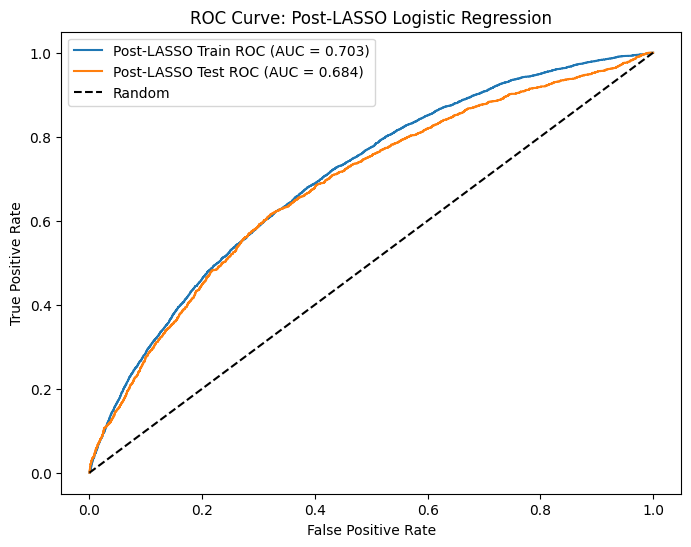

In [47]:
from sklearn.linear_model import LassoCV, Lasso, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve
import numpy as np
import matplotlib.pyplot as plt

X_train_fixed, y_train_fixed, X_test_fixed, y_test_fixed = datasets["fixed"]

scaler_lasso = StandardScaler()
X_train_scaled = scaler_lasso.fit_transform(X_train_fixed)
X_test_scaled = scaler_lasso.transform(X_test_fixed)

lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train_fixed)

optimal_alpha = lasso_cv.alpha_
print(f"Optimal lambda (alpha) from LassoCV: {optimal_alpha:.6f}")

lasso = Lasso(alpha=optimal_alpha, max_iter=10000)
lasso.fit(X_train_scaled, y_train_fixed)
coef_mask = lasso.coef_ != 0

selected_feature_indices = np.where(coef_mask)[0]
print(f"Selected feature indices by LASSO ({len(selected_feature_indices)}): {selected_feature_indices.tolist()}")

X_train_postlasso = X_train_fixed[:, selected_feature_indices]
X_test_postlasso = X_test_fixed[:, selected_feature_indices]

scaler_postlasso = StandardScaler()
X_train_postlasso_scaled = scaler_postlasso.fit_transform(X_train_postlasso)
X_test_postlasso_scaled = scaler_postlasso.transform(X_test_postlasso)

logreg_postlasso = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
logreg_postlasso.fit(X_train_postlasso_scaled, y_train_fixed)

test_pred_postlasso = logreg_postlasso.predict(X_test_postlasso_scaled)
test_proba_postlasso = logreg_postlasso.predict_proba(X_test_postlasso_scaled)[:, 1]
train_pred_postlasso = logreg_postlasso.predict(X_train_postlasso_scaled)
train_proba_postlasso = logreg_postlasso.predict_proba(X_train_postlasso_scaled)[:, 1]

train_acc_postlasso = accuracy_score(y_train_fixed, train_pred_postlasso)
test_acc_postlasso = accuracy_score(y_test_fixed, test_pred_postlasso)
train_misclass_postlasso = 1 - train_acc_postlasso
test_misclass_postlasso = 1 - test_acc_postlasso
auc_train_postlasso = roc_auc_score(y_train_fixed, train_proba_postlasso)
auc_test_postlasso = roc_auc_score(y_test_fixed, test_proba_postlasso)

print(f"Post-LASSO Logistic Regression Train accuracy: {train_acc_postlasso:.4f}, Test accuracy: {test_acc_postlasso:.4f}")
print(f"Post-LASSO Logistic Regression Train misclassification error: {train_misclass_postlasso:.4f}, Test misclassification error: {test_misclass_postlasso:.4f}")
print(f"Post-LASSO Logistic Regression Train AUC: {auc_train_postlasso:.4f}, Test AUC: {auc_test_postlasso:.4f}")

fpr_train_postlasso, tpr_train_postlasso, _ = roc_curve(y_train_fixed, train_proba_postlasso)
fpr_test_postlasso, tpr_test_postlasso, _ = roc_curve(y_test_fixed, test_proba_postlasso)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train_postlasso, tpr_train_postlasso, label=f"Post-LASSO Train ROC (AUC = {auc_train_postlasso:.3f})")
plt.plot(fpr_test_postlasso, tpr_test_postlasso, label=f"Post-LASSO Test ROC (AUC = {auc_test_postlasso:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Post-LASSO Logistic Regression")
plt.legend()
plt.show()


# L2 Regularization

c:\Users\jmani\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


Best alpha selected by CV: 483.2930238571752
Indices of features with nonzero coefficients (selected by RidgeCV): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]
RidgeCV Classifier Train accuracy: 0.7204
RidgeCV Classifier Train misclassification rate: 0.2796
RidgeCV Classifier Test accuracy: 0.6981
RidgeCV Classifier Test misclassification rate: 0.3019


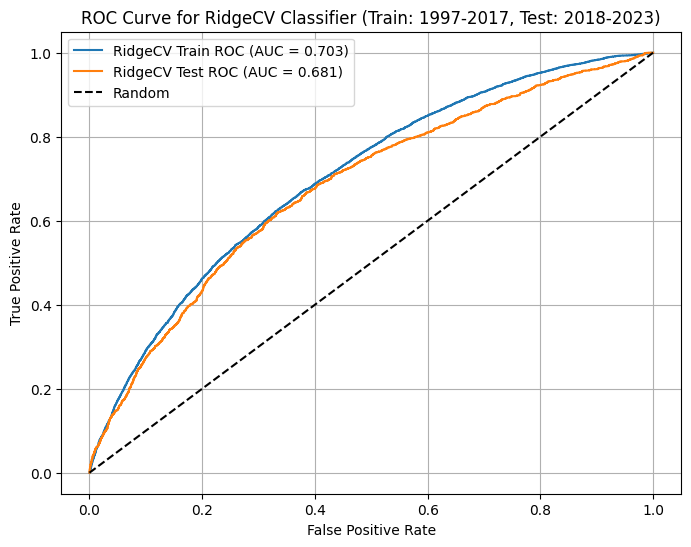

In [46]:
from sklearn.linear_model import RidgeClassifierCV
import numpy as np

scaler_ridgecv = StandardScaler()
X_train_ridgecv = scaler_ridgecv.fit_transform(X_train_fixed)
X_test_ridgecv = scaler_ridgecv.transform(X_test_fixed)

ridgecv_clf = RidgeClassifierCV(alphas=np.logspace(-3, 3, 20), store_cv_values=True)
ridgecv_clf.fit(X_train_ridgecv, y_train_fixed)

print(f"Best alpha selected by CV: {ridgecv_clf.alpha_}")

ridgecv_coefs = ridgecv_clf.coef_.ravel()
ridgecv_selected_indices = np.where(np.abs(ridgecv_coefs) > 1e-6)[0]
print("Indices of features with nonzero coefficients (selected by RidgeCV):", ridgecv_selected_indices.tolist())

train_pred_ridgecv = ridgecv_clf.predict(X_train_ridgecv)
train_acc_ridgecv = accuracy_score(y_train_fixed, train_pred_ridgecv)
train_misclass_ridgecv = 1 - train_acc_ridgecv
print(f"RidgeCV Classifier Train accuracy: {train_acc_ridgecv:.4f}")
print(f"RidgeCV Classifier Train misclassification rate: {train_misclass_ridgecv:.4f}")

test_pred_ridgecv = ridgecv_clf.predict(X_test_ridgecv)
test_acc_ridgecv = accuracy_score(y_test_fixed, test_pred_ridgecv)
test_misclass_ridgecv = 1 - test_acc_ridgecv
print(f"RidgeCV Classifier Test accuracy: {test_acc_ridgecv:.4f}")
print(f"RidgeCV Classifier Test misclassification rate: {test_misclass_ridgecv:.4f}")

train_score_ridgecv = ridgecv_clf.decision_function(X_train_ridgecv)
test_score_ridgecv = ridgecv_clf.decision_function(X_test_ridgecv)

fpr_train_ridgecv, tpr_train_ridgecv, _ = roc_curve(y_train_fixed, train_score_ridgecv)
fpr_test_ridgecv, tpr_test_ridgecv, _ = roc_curve(y_test_fixed, test_score_ridgecv)
auc_train_ridgecv = roc_auc_score(y_train_fixed, train_score_ridgecv)
auc_test_ridgecv = roc_auc_score(y_test_fixed, test_score_ridgecv)

plt.figure(figsize=(8, 6))
plt.plot(fpr_train_ridgecv, tpr_train_ridgecv, label=f"RidgeCV Train ROC (AUC = {auc_train_ridgecv:.3f})")
plt.plot(fpr_test_ridgecv, tpr_test_ridgecv, label=f"RidgeCV Test ROC (AUC = {auc_test_ridgecv:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for RidgeCV Classifier (Train: 1997-2017, Test: 2018-2023)")
plt.legend()
plt.grid(True)
plt.show()


## KNN

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {'n_neighbors': range(1, 50)}
knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train_fixed, y_train_fixed)
print(grid.best_params_)

{'n_neighbors': 49}


KNN Train accuracy: 0.7298
KNN Train misclassification rate: 0.2702
KNN Test accuracy: 0.6915
KNN Test misclassification rate: 0.3085


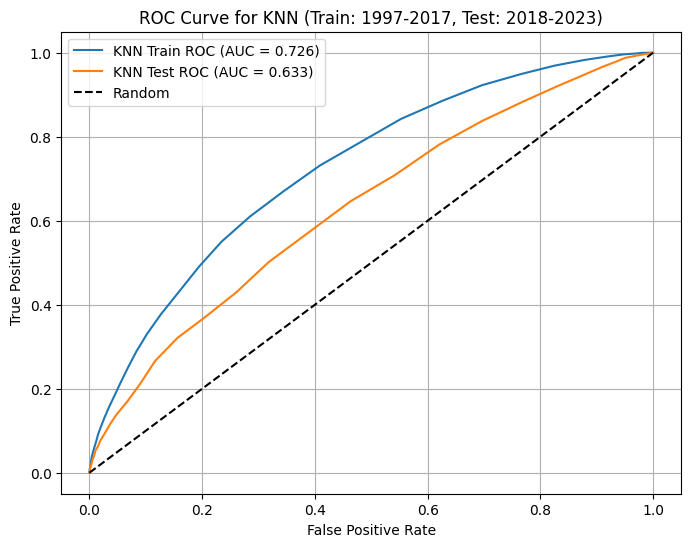

In [45]:

knn_pipeline = KNeighborsClassifier(n_neighbors=49)

# Fit on fixed window train set
knn_pipeline.fit(X_train_fixed, y_train_fixed)

# Predict and evaluate on train set
train_pred_knn = knn_pipeline.predict(X_train_fixed)
train_acc_knn = accuracy_score(y_train_fixed, train_pred_knn)
train_misclass_knn = 1 - train_acc_knn
print(f"KNN Train accuracy: {train_acc_knn:.4f}")
print(f"KNN Train misclassification rate: {train_misclass_knn:.4f}")

# Predict and evaluate on test set
test_pred_knn = knn_pipeline.predict(X_test_fixed)
test_acc_knn = accuracy_score(y_test_fixed, test_pred_knn)
test_misclass_knn = 1 - test_acc_knn
print(f"KNN Test accuracy: {test_acc_knn:.4f}")
print(f"KNN Test misclassification rate: {test_misclass_knn:.4f}")

# Compute predicted probabilities for ROC/AUC
train_proba_knn = knn_pipeline.predict_proba(X_train_fixed)[:, 1]
test_proba_knn = knn_pipeline.predict_proba(X_test_fixed)[:, 1]

# Compute ROC curve and AUC for train and test
fpr_train_knn, tpr_train_knn, _ = roc_curve(y_train_fixed, train_proba_knn)
fpr_test_knn, tpr_test_knn, _ = roc_curve(y_test_fixed, test_proba_knn)
auc_train_knn = roc_auc_score(y_train_fixed, train_proba_knn)
auc_test_knn = roc_auc_score(y_test_fixed, test_proba_knn)

# Plot ROC curves for KNN
plt.figure(figsize=(8, 6))
plt.plot(fpr_train_knn, tpr_train_knn, label=f"KNN Train ROC (AUC = {auc_train_knn:.3f})")
plt.plot(fpr_test_knn, tpr_test_knn, label=f"KNN Test ROC (AUC = {auc_test_knn:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for KNN (Train: 1997-2017, Test: 2018-2023)")
plt.legend()
plt.grid(True)
plt.show()


## XGBOOST

In [48]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier()

param_dist = {
    'max_depth': range(3, 10),
    'min_child_weight': range(1, 10),
    'subsample': [0.6,0.7,0.8,0.9,1.0],
    'colsample_bytree': [0.6,0.7,0.8,0.9,1.0],
    'gamma': [0, 0.1, 0.5, 1, 5]
}

rand_search = RandomizedSearchCV(xgb, param_dist, n_iter=50, cv=5, scoring='roc_auc', n_jobs=-1, random_state=42)
rand_search.fit(X_train_fixed, y_train_fixed)
print(rand_search.best_params_)

{'subsample': 0.9, 'min_child_weight': 9, 'max_depth': 3, 'gamma': 5, 'colsample_bytree': 1.0}


In [49]:


train_pred_xgb = rand_search.predict(X_train_fixed)
train_acc_xgb = accuracy_score(y_train_fixed, train_pred_xgb)
print(f"XGBoost Train accuracy: {train_acc_xgb:.4f}")

# Predict and evaluate on test set
test_pred_xgb = rand_search.predict(X_test_fixed)
test_acc_xgb = accuracy_score(y_test_fixed, test_pred_xgb)
print(f"XGBoost Test accuracy: {test_acc_xgb:.4f}")

# Compute predicted probabilities for ROC/AUC
train_proba_xgb = rand_search.predict_proba(X_train_fixed)[:, 1]
test_proba_xgb = rand_search.predict_proba(X_test_fixed)[:, 1]

# Compute ROC AUC for train and test
auc_train_xgb = roc_auc_score(y_train_fixed, train_proba_xgb)
auc_test_xgb = roc_auc_score(y_test_fixed, test_proba_xgb)
print(f"XGBoost Train ROC AUC: {auc_train_xgb:.4f}")
print(f"XGBoost Test ROC AUC: {auc_test_xgb:.4f}")


XGBoost Train accuracy: 0.7492
XGBoost Test accuracy: 0.6962
XGBoost Train ROC AUC: 0.7644
XGBoost Test ROC AUC: 0.6797
